In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

train_df = pd.read_csv("data/train.csv")
eval_df = pd.read_csv("data/eval.csv")

artists = sorted(train_df["artist"].unique())

In [3]:
import os
os.makedirs("../report/figures", exist_ok=True)

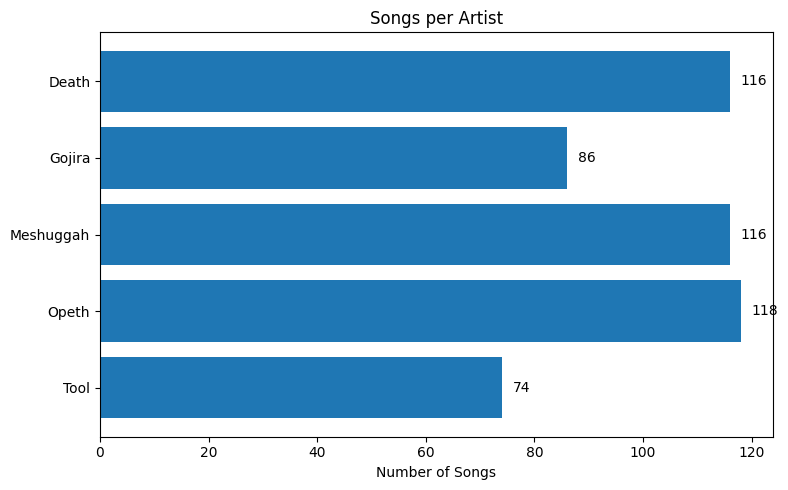

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = pd.concat([train_df, eval_df])["artist"].value_counts().reindex(artists)
ax.barh(artists, counts.values)
ax.set_xlabel("Number of Songs")
ax.set_title("Songs per Artist")
ax.invert_yaxis()
for i, v in enumerate(counts.values):
    ax.text(v + 2, i, str(v), va="center")
plt.tight_layout()
plt.savefig("../report/figures/artist_distribution.pdf", bbox_inches="tight")
plt.show()

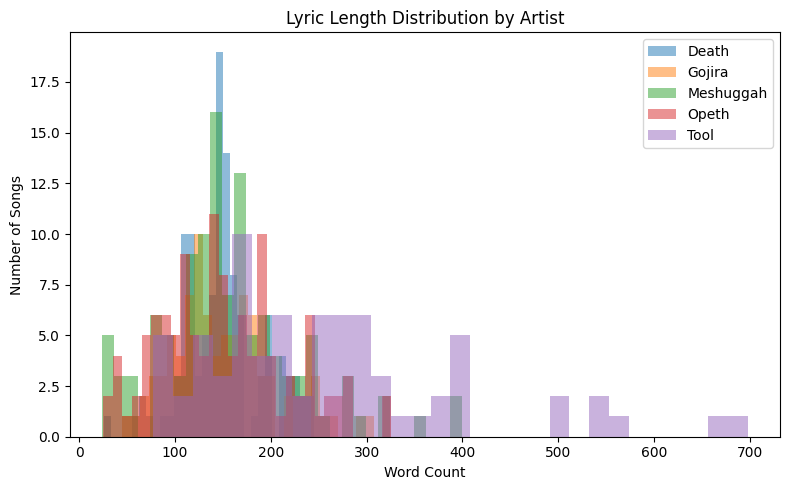

In [5]:
all_df = pd.concat([train_df, eval_df])
fig, ax = plt.subplots(figsize=(8, 5))
for artist in artists:
    lengths = all_df[all_df["artist"] == artist]["clean"].str.split().str.len()
    ax.hist(lengths, bins=30, alpha=0.5, label=artist)
ax.set_xlabel("Word Count")
ax.set_ylabel("Number of Songs")
ax.set_title("Lyric Length Distribution by Artist")
ax.legend()
plt.tight_layout()
plt.savefig("../report/figures/lyric_lengths.pdf", bbox_inches="tight")
plt.show()

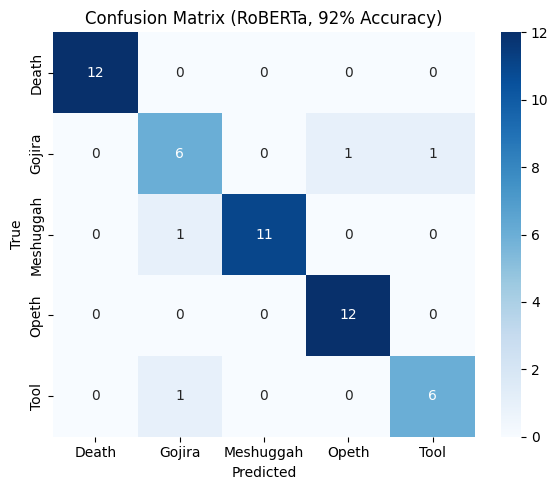

In [6]:
cm = np.array([
      [12, 0, 0, 0, 0],
      [0, 6, 0, 1, 1],
      [0, 1, 11, 0, 0],
      [0, 0, 0, 12, 0],
      [0, 1, 0, 0, 6],
  ])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=artists,
yticklabels=artists, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (RoBERTa, 92% Accuracy)")
plt.tight_layout()
plt.savefig("../report/figures/confusion_matrix.pdf", bbox_inches="tight")
plt.show()

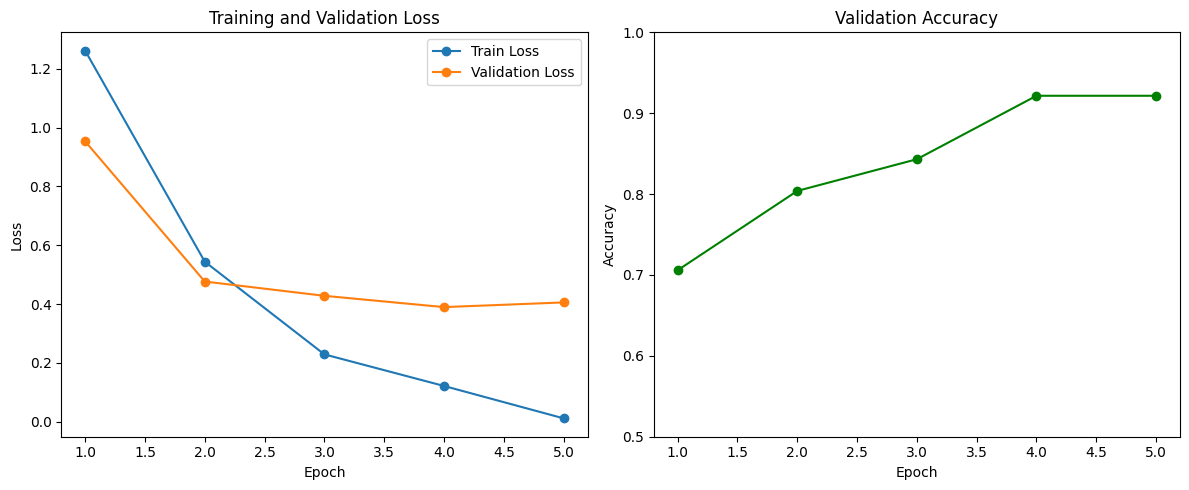

In [7]:
epochs = [1, 2, 3, 4, 5]
train_loss = [1.261016, 0.543941, 0.228934, 0.121621, 0.011556]
val_loss = [0.952847, 0.476524, 0.427971, 0.389617, 0.405523]
accuracy = [0.705882, 0.803922, 0.843137, 0.921569, 0.921569]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(epochs, train_loss, "o-", label="Train Loss")
ax1.plot(epochs, val_loss, "o-", label="Validation Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()

ax2.plot(epochs, accuracy, "o-", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy")
ax2.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig("../report/figures/training_curves.pdf", bbox_inches="tight")
plt.show()